In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statistics as stats
import matplotlib.pylab as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("dirty_cafe_sales.csv")

In [3]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [5]:
df.shape

(10000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [7]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


# Rename Columns

In [8]:
df = df.rename(columns={'Item': 'Smoothie', 'Location': 'Venue'})
df.head()

,Transaction ID,Smoothie,Quantity,Price Per Unit,Total Spent,Payment Method,Venue,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


# Check Missing Value

In [9]:
df.isnull().sum()

Transaction ID         0
Smoothie             333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Venue               3265
Transaction Date     159
dtype: int64

In [10]:
df.columns

Index(['Transaction ID', 'Smoothie', 'Quantity', 'Price Per Unit',
       'Total Spent', 'Payment Method', 'Venue', 'Transaction Date'],
      dtype='object')

In [11]:
df.describe()

,Transaction ID,Smoothie,Quantity,Price Per Unit,Total Spent,Payment Method,Venue,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [12]:
cat_col= ["Smoothie","Quantity","Price Per Unit","Total Spent","Payment Method","Venue","Transaction Date",]
for i in cat_col:
    df[i] = df[i].fillna(df[i].mode()[0])

In [13]:
df.isnull().sum()

Transaction ID      0
Smoothie            0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Venue               0
Transaction Date    0
dtype: int64

In [14]:
cat_col=df.select_dtypes(include="object").columns

In [15]:
cat_col

Index(['Transaction ID', 'Smoothie', 'Quantity', 'Price Per Unit',
       'Total Spent', 'Payment Method', 'Venue', 'Transaction Date'],
      dtype='object')

# Data Cleaning

In [16]:
df.head(2)

,Transaction ID,Smoothie,Quantity,Price Per Unit,Total Spent,Payment Method,Venue,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16


In [17]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce").fillna(0).astype(int)
df["Price Per Unit"] =pd.to_numeric(df["Price Per Unit"], errors="coerce").fillna(0).astype(int)
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce").fillna(0).astype(int)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Smoothie          10000 non-null  object
 2   Quantity          10000 non-null  int64 
 3   Price Per Unit    10000 non-null  int64 
 4   Total Spent       10000 non-null  int64 
 5   Payment Method    10000 non-null  object
 6   Venue             10000 non-null  object
 7   Transaction Date  10000 non-null  object
dtypes: int64(3), object(5)
memory usage: 625.1+ KB


In [19]:
df["Transaction Date"].value_counts()

Transaction Date
UNKNOWN       318
ERROR         142
2023-02-06     40
2023-06-16     40
2023-07-21     39
             ... 
2023-04-27     15
2023-09-24     15
2023-07-22     14
2023-03-11     14
2023-02-17     14
Name: count, Length: 367, dtype: int64

# Replace invalid values with NaN

In [20]:
df["Transaction Date"] = df["Transaction Date"].replace(
    ["UNKNOWN", "ERROR"],
    np.nan
)

In [21]:
df["Transaction Date"].value_counts()

Transaction Date
2023-02-06    40
2023-06-16    40
2023-03-13    39
2023-07-21    39
2023-09-21    39
              ..
2023-04-27    15
2023-11-24    15
2023-03-11    14
2023-02-17    14
2023-07-22    14
Name: count, Length: 365, dtype: int64

# Change Data Type

In [22]:
def change_into_datatime(col):
    df[col]=pd.to_datetime(df[col])

In [23]:
for i in ["Transaction Date"]:
    change_into_datatime(i)

In [24]:
df['Tran_day'] = pd.to_datetime(df['Transaction Date'],format = '%d%m%y').dt.day
df['Tran_month'] = pd.to_datetime(df['Transaction Date'],format = '%d%m%y').dt.month
df['Tran_year'] = pd.to_datetime(df['Transaction Date'],format = '%d%m%y').dt.year

In [25]:
df.isnull().sum()

Transaction ID        0
Smoothie              0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Venue                 0
Transaction Date    460
Tran_day            460
Tran_month          460
Tran_year           460
dtype: int64

In [26]:
del df["Transaction Date"]

In [27]:
num_col =["Tran_day","Tran_month","Tran_year"]
for i in num_col:
    df[i].fillna(df[i].mean(),inplace=True)

In [28]:
df.isnull().sum()

Transaction ID    0
Smoothie          0
Quantity          0
Price Per Unit    0
Total Spent       0
Payment Method    0
Venue             0
Tran_day          0
Tran_month        0
Tran_year         0
dtype: int64

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction ID  10000 non-null  object 
 1   Smoothie        10000 non-null  object 
 2   Quantity        10000 non-null  int64  
 3   Price Per Unit  10000 non-null  int64  
 4   Total Spent     10000 non-null  int64  
 5   Payment Method  10000 non-null  object 
 6   Venue           10000 non-null  object 
 7   Tran_day        10000 non-null  float64
 8   Tran_month      10000 non-null  float64
 9   Tran_year       10000 non-null  float64
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB


In [31]:
num_cols = ['P_day','P_month','P_year']
for i in num_cols:
    df[num_col] = df[num_col].astype(int)

In [32]:
df.head()

,Transaction ID,Smoothie,Quantity,Price Per Unit,Total Spent,Payment Method,Venue,Tran_day,Tran_month,Tran_year
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,8,9,2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,16,5,2023
2,TXN_4271903,Cookie,4,1,0,Credit Card,In-store,19,7,2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,27,4,2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,11,6,2023


In [33]:
df["Transaction ID"] = df["Transaction ID"].str.replace("TXN_", "", regex = False)
df.head()

,Transaction ID,Smoothie,Quantity,Price Per Unit,Total Spent,Payment Method,Venue,Tran_day,Tran_month,Tran_year
0,1961373,Coffee,2,2,4,Credit Card,Takeaway,8,9,2023
1,4977031,Cake,4,3,12,Cash,In-store,16,5,2023
2,4271903,Cookie,4,1,0,Credit Card,In-store,19,7,2023
3,7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,27,4,2023
4,3160411,Coffee,2,2,4,Digital Wallet,In-store,11,6,2023


In [34]:
df["Transaction ID"] = pd.to_numeric(df["Transaction ID"], errors="coerce").fillna(0).astype(int)

In [35]:
df["Smoothie"].value_counts()

Smoothie
Juice       1504
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64

In [36]:
df["Smoothie"]=np.where(df["Smoothie"] == "UNKNOWN","Tea",df["Smoothie"])
df["Smoothie"]=np.where(df["Smoothie"] == "ERROR","Coffee",df["Smoothie"])

In [37]:
df["Smoothie"].value_counts()

Smoothie
Juice       1504
Coffee      1457
Tea         1433
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Name: count, dtype: int64

In [38]:
df["Payment Method"].value_counts()

Payment Method
Digital Wallet    4870
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

In [39]:
df["Payment Method"]=np.where(df["Payment Method"] == "ERROR","UNKNOWN",df["Payment Method"])

In [40]:
df["Payment Method"].value_counts()

Payment Method
Digital Wallet    4870
Credit Card       2273
Cash              2258
UNKNOWN            599
Name: count, dtype: int64

In [41]:
df["Venue"].value_counts()

Venue
Takeaway    6287
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64

In [42]:
df["Venue"]=np.where(df["Venue"] == "ERROR","UNKNOWN",df["Venue"])

In [43]:
df["Venue"].value_counts()

Venue
Takeaway    6287
In-store    3017
UNKNOWN      696
Name: count, dtype: int64

# DATA VISUALISATION

In [44]:
df.skew(numeric_only=True)

Transaction ID    0.019401
Quantity         -0.099883
Price Per Unit   -0.145553
Total Spent       0.816949
Tran_day          0.020889
Tran_month        0.005533
Tran_year         0.000000
dtype: float64

In [48]:
df["Tran_year"].value_counts()

Tran_year
2023    10000
Name: count, dtype: int64

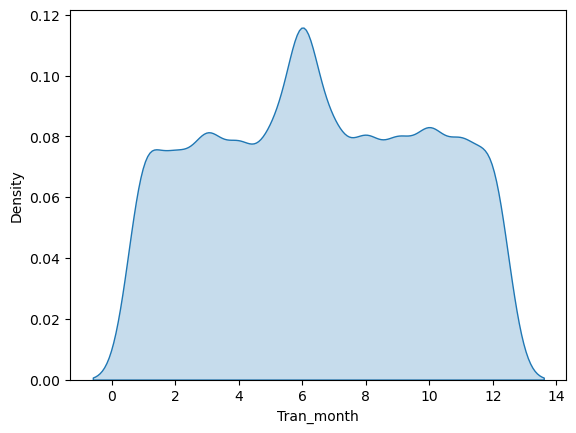

In [49]:
sns.kdeplot(df["Tran_month"], shade=True)
plt.show()

In [50]:
df.head()

,Transaction ID,Smoothie,Quantity,Price Per Unit,Total Spent,Payment Method,Venue,Tran_day,Tran_month,Tran_year
0,1961373,Coffee,2,2,4,Credit Card,Takeaway,8,9,2023
1,4977031,Cake,4,3,12,Cash,In-store,16,5,2023
2,4271903,Cookie,4,1,0,Credit Card,In-store,19,7,2023
3,7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,27,4,2023
4,3160411,Coffee,2,2,4,Digital Wallet,In-store,11,6,2023


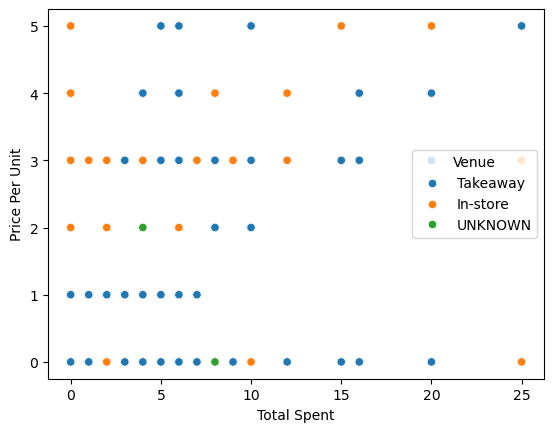

In [52]:
sns.scatterplot(x="Total Spent",y="Price Per Unit", hue="Venue",data=df)
plt.show()

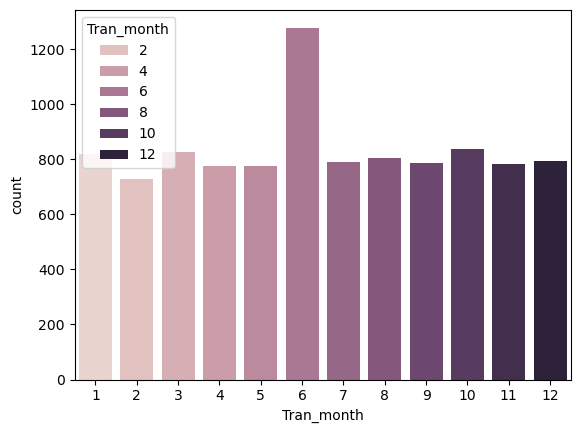

In [53]:
sns.countplot(x="Tran_month", data=df, hue="Tran_month")
plt.show()

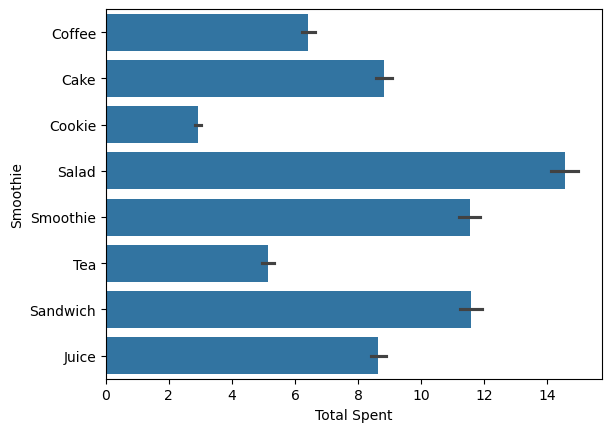

In [54]:
sns.barplot(x="Total Spent", y="Smoothie" , data=df)
plt.show()

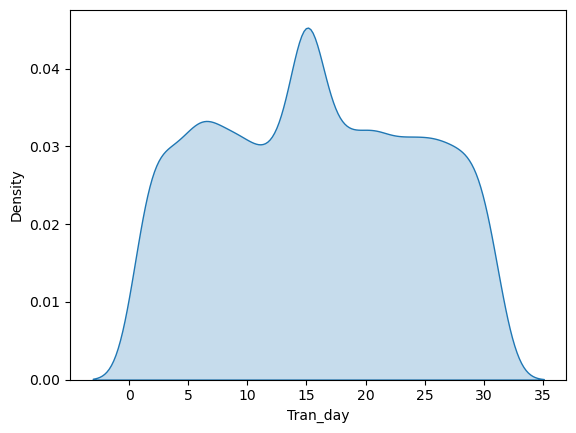

In [55]:
sns.kdeplot(df["Tran_day"], shade=True)
plt.show()

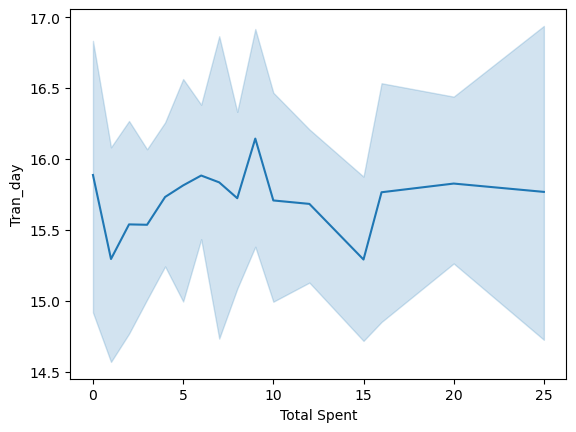

In [56]:
sns.lineplot(x="Total Spent",y="Tran_day",data=df)
plt.show()

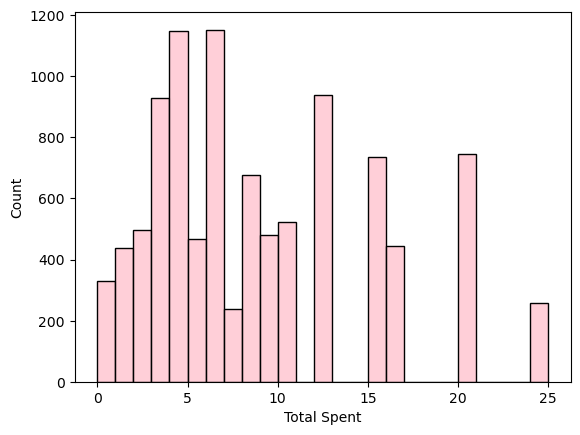

In [58]:
sns.histplot(df["Total Spent"],bins=25,color="pink")
plt.show()

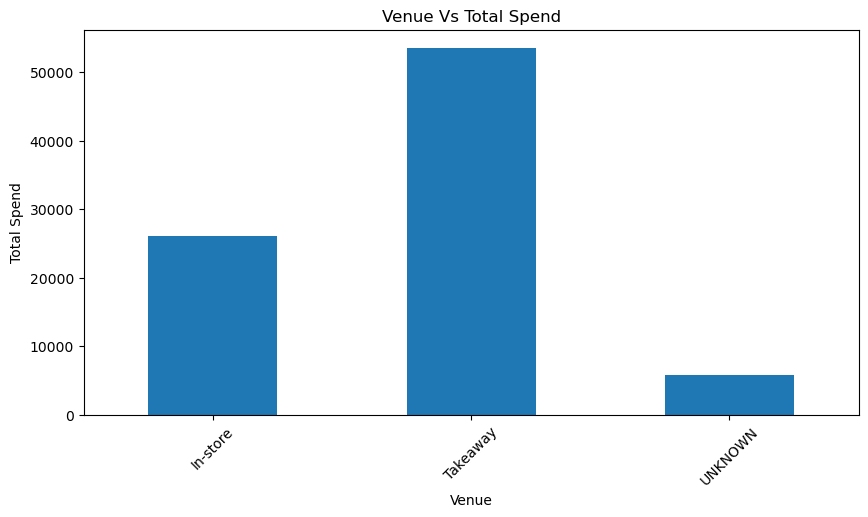

In [60]:
# Group by Venue and Calculate Total Spent

venue_spend = df.groupby('Venue')['Total Spent'].sum()

# create bar group
plt.figure(figsize=(10,5))
venue_spend.plot(kind='bar')

# Lables and title
plt.xlabel('Venue')
plt.ylabel('Total Spend')
plt.title('Venue Vs Total Spend')

plt.xticks(rotation=45)
plt.show()